# **EXERCISE 1**




In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.5 MB/s eta 0:00:00


In [3]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
from transformers import (
    BertModel,
    BertForSequenceClassification,
    BertTokenizer,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Loading and Previewing the Yelp English Training Dataset

In [7]:
df = pd.read_csv('/content/drive/MyDrive/NLP2025/yelp/yelp/train_en.txt', sep='\t')
df.head()

,Sentence,Style,User
0,Cute interior and owner (?) gave us tour of up...,positive,bcjbaE6dDog4jkNY91ncLQ
1,I've been to this location many times when I l...,negative,enaHB1e956thdnafcHVAig
2,My food only merited maybe two stars but I wil...,negative,07aVWNhBhpwqW3MdqoKDKQ
3,After trying a few ramen places with crazy var...,negative,OkjeFppodgJP_CvB84cJYw
4,I cannot even believe someone gave this place ...,positive,7Ie0VmQtnGYUVq2YW4dTVw


In [3]:
len(df)

342905

Loading Pretrained Tokenizers for RoBERTa and DistilBERT

In [8]:
model_name1 = "roberta-base"
model_name2 = "distilbert-base-uncased"
tokenizer1 = AutoTokenizer.from_pretrained(model_name1)
tokenizer2 = AutoTokenizer.from_pretrained(model_name2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizing Train Sentences Using a Pretrained Tokenizer

In [5]:
def tokenize(row):
    enc = tokenizer1(
        row["Sentence"],
        truncation=True,
        padding="max_length",
        max_length=256
    )
    return pd.Series(enc)

df_tokens = df.copy()
df_tokens[["input_ids", "attention_mask"]] = df.apply(tokenize, axis=1)
df_tokens

,Sentence,Style,User,input_ids,attention_mask
0,Cute interior and owner (?) gave us tour of up...,positive,bcjbaE6dDog4jkNY91ncLQ,"[0, 347, 4467, 6291, 8, 1945, 36, 16276, 851, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,I've been to this location many times when I l...,negative,enaHB1e956thdnafcHVAig,"[0, 100, 348, 57, 7, 42, 2259, 171, 498, 77, 3...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,My food only merited maybe two stars but I wil...,negative,07aVWNhBhpwqW3MdqoKDKQ,"[0, 2387, 689, 129, 9374, 4560, 2085, 80, 2690...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,After trying a few ramen places with crazy var...,negative,OkjeFppodgJP_CvB84cJYw,"[0, 4993, 667, 10, 367, 19634, 225, 2127, 19, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,I cannot even believe someone gave this place ...,positive,7Ie0VmQtnGYUVq2YW4dTVw,"[0, 100, 1395, 190, 679, 951, 851, 42, 317, 65...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...,...,...
342900,So I've belonged to a gym for YEARS and I fina...,positive,O5y7KlfBdqV6Ih8yhjZLsg,"[0, 2847, 38, 348, 14574, 7, 10, 6545, 13, 225...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
342901,"ice cream! ice cream sodas, sundaes!! \n\nwant...",positive,7ziWZULyiZv2TesYNMFf4g,"[0, 2463, 6353, 328, 2480, 6353, 27928, 281, 6...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
342902,This is a good pizza option - they deliver thr...,negative,MCzlzlOw7IGbRAKVjJBPtg,"[0, 713, 16, 10, 205, 9366, 1973, 111, 51, 243...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
342903,Don't misinterpret my 5-star review....I don't...,positive,x1QLCwZGFAjxRRw4EHc3-g,"[0, 6766, 75, 36939, 127, 195, 12, 3641, 1551,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


Loading and Previewing the Yelp English Validation Dataset

In [9]:
df_val = pd.read_csv('/content/drive/MyDrive/NLP2025/yelp/yelp/val_en.txt', sep='\t')
df_val.head(10)

,Sentence,Style,User
0,A wee bit pricey for the portions they serve. ...,positive,ci7Q6NvXQ8UZrBHusVX18g
1,Cute lil spot on Germantown Ave. I came in cra...,positive,0rZEWmL2rccd-N5VMzKLiQ
2,They have great prices if you order family sty...,positive,3x69a8OGyReKirigOk8Nww
3,"Let's be honest, this place needs a face lift....",negative,7OUAzKZj6LUrQ3G7g7yUSw
4,Monthly lunch with my fellow colleagues the ot...,negative,zBWSORvlWDmwtcx6627qWQ
5,I have been going to this dive bar for years. ...,positive,DD9G_OSTN2xCjOBxHozTIA
6,Really great place for wine!\n\nCame here with...,positive,rpUOaLv_7QkDeFQSZMZhOg
7,"Still running on EST, we arrived @8:30 on a Sa...",negative,8RcEwGrFIgkt9WQ35E6SnQ
8,Some of the fare on offer at That BBQ Place is...,negative,R-c5M0iJkMxxTxIqTQQZ8w
9,I have been a fan of Charlie's for many years ...,positive,KFV9jDa1Lb36nZ5MGcrVcQ


Tokenizing Validation Sentences Using a Pretrained Tokenizer

In [9]:
def tokenize(row):
    enc = tokenizer1(
        row["Sentence"],
        truncation=True,
        padding="max_length",
        max_length=256
    )
    return pd.Series(enc)

df_tokens_val = df_val.copy()
df_tokens_val[["input_ids", "attention_mask"]] = df_val.apply(tokenize, axis=1)
df_tokens_val

,Sentence,Style,User,input_ids,attention_mask
0,A wee bit pricey for the portions they serve. ...,positive,ci7Q6NvXQ8UZrBHusVX18g,"[0, 250, 29295, 828, 26428, 13, 5, 14566, 51, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,Cute lil spot on Germantown Ave. I came in cra...,positive,0rZEWmL2rccd-N5VMzKLiQ,"[0, 347, 4467, 38101, 1514, 15, 24063, 927, 33...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,They have great prices if you order family sty...,positive,3x69a8OGyReKirigOk8Nww,"[0, 1213, 33, 372, 850, 114, 47, 645, 284, 249...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,"Let's be honest, this place needs a face lift....",negative,7OUAzKZj6LUrQ3G7g7yUSw,"[0, 7939, 18, 28, 5322, 6, 42, 317, 782, 10, 6...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,Monthly lunch with my fellow colleagues the ot...,negative,zBWSORvlWDmwtcx6627qWQ,"[0, 43299, 352, 4592, 19, 127, 2598, 4025, 5, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...,...,...
42858,My sister lived in this area as a teenager. I ...,positive,X4a1WSMYCfG6H46Fc34CUg,"[0, 2387, 2761, 3033, 11, 42, 443, 25, 10, 704...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
42859,Went here last Thursday with coworker who reco...,positive,6yMeRe_UQMfN1ukGRYhQsA,"[0, 771, 1342, 259, 94, 296, 19, 37966, 254, 5...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
42860,Great bagels and cupcakes here for the vegan a...,positive,Vjb8dsOwTXQU-4bdmNzfbw,"[0, 19065, 3298, 2507, 8, 4946, 33579, 259, 13...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
42861,I'll preface this review by saying I never eat...,positive,SVJvTooDYFA2OJn1vU_ofA,"[0, 100, 581, 1198, 9021, 42, 1551, 30, 584, 3...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


Creating a Custom PyTorch Dataset for Sentiment Classification

In [10]:
class SentimentDataset(Dataset):
    def __init__(self, data):
        self.input_ids = data["input_ids"].tolist()
        self.attention_mask = data["attention_mask"].tolist()
        self.labels = data["Style"].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx]),
            "attention_mask": torch.tensor(self.attention_mask[idx]),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


Encoding Train Sentiment Labels as Numeric Values

In [12]:
df_tokens["Style"] = df_tokens["Style"].str.lower().map({
    "positive": 1,
    "negative": 0
})

df_tokens

,Sentence,Style,User,input_ids,attention_mask
0,Cute interior and owner (?) gave us tour of up...,1,bcjbaE6dDog4jkNY91ncLQ,"[0, 347, 4467, 6291, 8, 1945, 36, 16276, 851, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,I've been to this location many times when I l...,0,enaHB1e956thdnafcHVAig,"[0, 100, 348, 57, 7, 42, 2259, 171, 498, 77, 3...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,My food only merited maybe two stars but I wil...,0,07aVWNhBhpwqW3MdqoKDKQ,"[0, 2387, 689, 129, 9374, 4560, 2085, 80, 2690...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,After trying a few ramen places with crazy var...,0,OkjeFppodgJP_CvB84cJYw,"[0, 4993, 667, 10, 367, 19634, 225, 2127, 19, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,I cannot even believe someone gave this place ...,1,7Ie0VmQtnGYUVq2YW4dTVw,"[0, 100, 1395, 190, 679, 951, 851, 42, 317, 65...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...,...,...
342900,So I've belonged to a gym for YEARS and I fina...,1,O5y7KlfBdqV6Ih8yhjZLsg,"[0, 2847, 38, 348, 14574, 7, 10, 6545, 13, 225...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
342901,"ice cream! ice cream sodas, sundaes!! \n\nwant...",1,7ziWZULyiZv2TesYNMFf4g,"[0, 2463, 6353, 328, 2480, 6353, 27928, 281, 6...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
342902,This is a good pizza option - they deliver thr...,0,MCzlzlOw7IGbRAKVjJBPtg,"[0, 713, 16, 10, 205, 9366, 1973, 111, 51, 243...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
342903,Don't misinterpret my 5-star review....I don't...,1,x1QLCwZGFAjxRRw4EHc3-g,"[0, 6766, 75, 36939, 127, 195, 12, 3641, 1551,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


Encoding Validation Sentiment Labels as Numeric Values




In [13]:
df_tokens_val["Style"] = df_tokens_val["Style"].str.lower().map({
    "positive": 1,
    "negative": 0
})

df_tokens_val

,Sentence,Style,User,input_ids,attention_mask
0,A wee bit pricey for the portions they serve. ...,1,ci7Q6NvXQ8UZrBHusVX18g,"[0, 250, 29295, 828, 26428, 13, 5, 14566, 51, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,Cute lil spot on Germantown Ave. I came in cra...,1,0rZEWmL2rccd-N5VMzKLiQ,"[0, 347, 4467, 38101, 1514, 15, 24063, 927, 33...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,They have great prices if you order family sty...,1,3x69a8OGyReKirigOk8Nww,"[0, 1213, 33, 372, 850, 114, 47, 645, 284, 249...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,"Let's be honest, this place needs a face lift....",0,7OUAzKZj6LUrQ3G7g7yUSw,"[0, 7939, 18, 28, 5322, 6, 42, 317, 782, 10, 6...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,Monthly lunch with my fellow colleagues the ot...,0,zBWSORvlWDmwtcx6627qWQ,"[0, 43299, 352, 4592, 19, 127, 2598, 4025, 5, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...,...,...
42858,My sister lived in this area as a teenager. I ...,1,X4a1WSMYCfG6H46Fc34CUg,"[0, 2387, 2761, 3033, 11, 42, 443, 25, 10, 704...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
42859,Went here last Thursday with coworker who reco...,1,6yMeRe_UQMfN1ukGRYhQsA,"[0, 771, 1342, 259, 94, 296, 19, 37966, 254, 5...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
42860,Great bagels and cupcakes here for the vegan a...,1,Vjb8dsOwTXQU-4bdmNzfbw,"[0, 19065, 3298, 2507, 8, 4946, 33579, 259, 13...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
42861,I'll preface this review by saying I never eat...,1,SVJvTooDYFA2OJn1vU_ofA,"[0, 100, 581, 1198, 9021, 42, 1551, 30, 584, 3...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [16]:
dataset_train = SentimentDataset(data=df_tokens)
dataset_train

In [17]:
dataset_val = SentimentDataset(data=df_tokens_val)
dataset_val

Defining Evaluation Metrics for Model Performance

In [19]:
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

Training a RoBERTa Transformer Model for Sequence Classification Using Hugging Face Trainer

In [51]:
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification

def train_model(model_name, learning_rate=3e-5, epochs=3, batch_size=32):
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"./results_{model_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,

        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size*2,
        gradient_accumulation_steps=2,         # → effective batch = 128 (perfect)
        num_train_epochs=epochs,

        weight_decay=0.01,                     # Standard value
        warmup_ratio=0.1,

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        fp16=True,                             # ← 2–4× speedup on Colab GPU
        dataloader_num_workers=4,
        gradient_checkpointing=True,

        report_to="none",                      # No wandb
        seed=42,
        disable_tqdm=False,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=torch.utils.data.Subset(dataset_train, range(100000)),
        eval_dataset=dataset_val,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_result = trainer.evaluate()
    print("\nFinal Evaluation:", eval_result)
    return eval_result, trainer

Training RoBERTa-Base Model for Sentiment Classification



In [49]:
result_roberta, trainer_roberta = train_model(
    model_name=model_name1,
    learning_rate=3e-5,
    epochs=3,
    batch_size=32)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.205000,0.196072,0.923780,0.929742,0.967199,0.948101
2,0.146600,0.203791,0.925484,0.933241,0.965546,0.949119


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.205000,0.196072,0.923780,0.929742,0.967199,0.948101
2,0.146600,0.203791,0.925484,0.933241,0.965546,0.949119
3,0.108000,0.220352,0.925577,0.939863,0.957897,0.948795


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



Final Evaluation: {'eval_loss': 0.20379066467285156, 'eval_accuracy': 0.9254835172526421, 'eval_precision': 0.9332414398045173, 'eval_recall': 0.9655463001977117, 'eval_f1': 0.9491190620320515, 'eval_runtime': 135.3647, 'eval_samples_per_second': 316.648, 'eval_steps_per_second': 4.95, 'epoch': 3.0}


Tokenizing Train Sentences Using a Pretrained Tokenizer (DistilBERT)

In [11]:
def tokenize(row):
    enc = tokenizer2(
        row["Sentence"],
        truncation=True,
        padding="max_length",
        max_length=256
    )
    return pd.Series(enc)

df_tokens_distilbert = df.copy()
df_tokens_distilbert[["input_ids", "attention_mask"]] = df.apply(tokenize, axis=1)
df_tokens_distilbert

,Sentence,Style,User,input_ids,attention_mask
0,Cute interior and owner (?) gave us tour of up...,positive,bcjbaE6dDog4jkNY91ncLQ,"[101, 10140, 4592, 1998, 3954, 1006, 1029, 100...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,I've been to this location many times when I l...,negative,enaHB1e956thdnafcHVAig,"[101, 1045, 1005, 2310, 2042, 2000, 2023, 3295...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,My food only merited maybe two stars but I wil...,negative,07aVWNhBhpwqW3MdqoKDKQ,"[101, 2026, 2833, 2069, 7857, 2098, 2672, 2048...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,After trying a few ramen places with crazy var...,negative,OkjeFppodgJP_CvB84cJYw,"[101, 2044, 2667, 1037, 2261, 8223, 2368, 3182...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,I cannot even believe someone gave this place ...,positive,7Ie0VmQtnGYUVq2YW4dTVw,"[101, 1045, 3685, 2130, 2903, 2619, 2435, 2023...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...,...,...
342900,So I've belonged to a gym for YEARS and I fina...,positive,O5y7KlfBdqV6Ih8yhjZLsg,"[101, 2061, 1045, 1005, 2310, 6272, 2000, 1037...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
342901,"ice cream! ice cream sodas, sundaes!! \n\nwant...",positive,7ziWZULyiZv2TesYNMFf4g,"[101, 3256, 6949, 999, 3256, 6949, 14904, 2015...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
342902,This is a good pizza option - they deliver thr...,negative,MCzlzlOw7IGbRAKVjJBPtg,"[101, 2023, 2003, 1037, 2204, 10733, 5724, 101...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
342903,Don't misinterpret my 5-star review....I don't...,positive,x1QLCwZGFAjxRRw4EHc3-g,"[101, 2123, 1005, 1056, 28616, 18447, 2121, 28...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


Tokenizing Validation Sentences Using a Pretrained Tokenizer (DistilBERT)

In [12]:
def tokenize(row):
    enc = tokenizer2(
        row["Sentence"],
        truncation=True,
        padding="max_length",
        max_length=256
    )
    return pd.Series(enc)

df_tokens_val_distilbert= df_val.copy()
df_tokens_val_distilbert[["input_ids", "attention_mask"]] = df_val.apply(tokenize, axis=1)
df_tokens_val_distilbert

,Sentence,Style,User,input_ids,attention_mask
0,A wee bit pricey for the portions they serve. ...,positive,ci7Q6NvXQ8UZrBHusVX18g,"[101, 1037, 16776, 2978, 3976, 2100, 2005, 199...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,Cute lil spot on Germantown Ave. I came in cra...,positive,0rZEWmL2rccd-N5VMzKLiQ,"[101, 10140, 13451, 3962, 2006, 2446, 4665, 13...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,They have great prices if you order family sty...,positive,3x69a8OGyReKirigOk8Nww,"[101, 2027, 2031, 2307, 7597, 2065, 2017, 2344...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,"Let's be honest, this place needs a face lift....",negative,7OUAzKZj6LUrQ3G7g7yUSw,"[101, 2292, 1005, 1055, 2022, 7481, 1010, 2023...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,Monthly lunch with my fellow colleagues the ot...,negative,zBWSORvlWDmwtcx6627qWQ,"[101, 7058, 6265, 2007, 2026, 3507, 8628, 1996...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...,...,...
42858,My sister lived in this area as a teenager. I ...,positive,X4a1WSMYCfG6H46Fc34CUg,"[101, 2026, 2905, 2973, 1999, 2023, 2181, 2004...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
42859,Went here last Thursday with coworker who reco...,positive,6yMeRe_UQMfN1ukGRYhQsA,"[101, 2253, 2182, 2197, 9432, 2007, 11190, 295...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
42860,Great bagels and cupcakes here for the vegan a...,positive,Vjb8dsOwTXQU-4bdmNzfbw,"[101, 2307, 4524, 9050, 1998, 2452, 17955, 201...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
42861,I'll preface this review by saying I never eat...,positive,SVJvTooDYFA2OJn1vU_ofA,"[101, 1045, 1005, 2222, 18443, 2023, 3319, 201...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


Encoding Train Sentiment Labels as Numeric Values


In [13]:
df_tokens_distilbert["Style"] = df_tokens_distilbert["Style"].str.lower().map({
    "positive": 1,
    "negative": 0
})

df_tokens_distilbert

,Sentence,Style,User,input_ids,attention_mask
0,Cute interior and owner (?) gave us tour of up...,1,bcjbaE6dDog4jkNY91ncLQ,"[101, 10140, 4592, 1998, 3954, 1006, 1029, 100...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,I've been to this location many times when I l...,0,enaHB1e956thdnafcHVAig,"[101, 1045, 1005, 2310, 2042, 2000, 2023, 3295...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,My food only merited maybe two stars but I wil...,0,07aVWNhBhpwqW3MdqoKDKQ,"[101, 2026, 2833, 2069, 7857, 2098, 2672, 2048...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,After trying a few ramen places with crazy var...,0,OkjeFppodgJP_CvB84cJYw,"[101, 2044, 2667, 1037, 2261, 8223, 2368, 3182...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,I cannot even believe someone gave this place ...,1,7Ie0VmQtnGYUVq2YW4dTVw,"[101, 1045, 3685, 2130, 2903, 2619, 2435, 2023...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...,...,...
342900,So I've belonged to a gym for YEARS and I fina...,1,O5y7KlfBdqV6Ih8yhjZLsg,"[101, 2061, 1045, 1005, 2310, 6272, 2000, 1037...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
342901,"ice cream! ice cream sodas, sundaes!! \n\nwant...",1,7ziWZULyiZv2TesYNMFf4g,"[101, 3256, 6949, 999, 3256, 6949, 14904, 2015...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
342902,This is a good pizza option - they deliver thr...,0,MCzlzlOw7IGbRAKVjJBPtg,"[101, 2023, 2003, 1037, 2204, 10733, 5724, 101...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
342903,Don't misinterpret my 5-star review....I don't...,1,x1QLCwZGFAjxRRw4EHc3-g,"[101, 2123, 1005, 1056, 28616, 18447, 2121, 28...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [14]:
dataset_train2 = SentimentDataset(data=df_tokens_distilbert)
dataset_train2

Encoding Validation Sentiment Labels as Numeric Values


In [15]:
df_tokens_val_distilbert["Style"] = df_tokens_val_distilbert["Style"].str.lower().map({
    "positive": 1,
    "negative": 0
})

df_tokens_val_distilbert

,Sentence,Style,User,input_ids,attention_mask
0,A wee bit pricey for the portions they serve. ...,1,ci7Q6NvXQ8UZrBHusVX18g,"[101, 1037, 16776, 2978, 3976, 2100, 2005, 199...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,Cute lil spot on Germantown Ave. I came in cra...,1,0rZEWmL2rccd-N5VMzKLiQ,"[101, 10140, 13451, 3962, 2006, 2446, 4665, 13...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,They have great prices if you order family sty...,1,3x69a8OGyReKirigOk8Nww,"[101, 2027, 2031, 2307, 7597, 2065, 2017, 2344...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,"Let's be honest, this place needs a face lift....",0,7OUAzKZj6LUrQ3G7g7yUSw,"[101, 2292, 1005, 1055, 2022, 7481, 1010, 2023...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,Monthly lunch with my fellow colleagues the ot...,0,zBWSORvlWDmwtcx6627qWQ,"[101, 7058, 6265, 2007, 2026, 3507, 8628, 1996...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...,...,...
42858,My sister lived in this area as a teenager. I ...,1,X4a1WSMYCfG6H46Fc34CUg,"[101, 2026, 2905, 2973, 1999, 2023, 2181, 2004...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
42859,Went here last Thursday with coworker who reco...,1,6yMeRe_UQMfN1ukGRYhQsA,"[101, 2253, 2182, 2197, 9432, 2007, 11190, 295...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
42860,Great bagels and cupcakes here for the vegan a...,1,Vjb8dsOwTXQU-4bdmNzfbw,"[101, 2307, 4524, 9050, 1998, 2452, 17955, 201...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
42861,I'll preface this review by saying I never eat...,1,SVJvTooDYFA2OJn1vU_ofA,"[101, 1045, 1005, 2222, 18443, 2023, 3319, 201...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [16]:
dataset_val2 = SentimentDataset(data=df_tokens_val_distilbert)
dataset_val2

Training a DistilBERT Transformer Model for Sequence Classification Using Hugging Face Trainer

In [20]:
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification

def train_model(model_name, learning_rate=3e-5, epochs=3, batch_size=32):
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"./results_{model_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,

        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size*2,
        gradient_accumulation_steps=2,         # → effective batch = 128 (perfect)
        num_train_epochs=epochs,

        weight_decay=0.01,                     # Standard value
        warmup_ratio=0.1,

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        fp16=True,                             # ← 2–4× speedup on Colab GPU
        dataloader_num_workers=4,
        gradient_checkpointing=True,

        report_to="none",                      # No wandb
        seed=42,
        disable_tqdm=False,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=torch.utils.data.Subset(dataset_train2, range(100000)),
        eval_dataset=dataset_val2,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_result = trainer.evaluate()
    print("\nFinal Evaluation:", eval_result)
    return eval_result, trainer

Training DistilBERT-Base Model for Sentiment Classification


In [21]:
result_distilbert, trainer_roberta = train_model(
    model_name=model_name2,
    learning_rate=3e-5,
    epochs=3,
    batch_size=32)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.218000,0.219167,0.912232,0.921178,0.960231,0.940299
2,0.169500,0.223828,0.914938,0.921853,0.963504,0.942219
3,0.107900,0.246641,0.913165,0.929791,0.951188,0.940368


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: T


Final Evaluation: {'eval_loss': 0.22382788360118866, 'eval_accuracy': 0.9149382917667919, 'eval_precision': 0.9218531956461066, 'eval_recall': 0.9635043593815836, 'eval_f1': 0.9422187004754358, 'eval_runtime': 72.4229, 'eval_samples_per_second': 591.843, 'eval_steps_per_second': 9.251, 'epoch': 3.0}


## TESTING RoBERTa

In [12]:
!ls -la ./results_distilbert-base-uncased

ls: cannot access './results_distilbert-base-uncased': No such file or directory


Due to Google Colab’s session timeout limitations (maximum ~12 hours) and automatic deletion of all files upon runtime restart, the fully trained RoBERTa-base model was not persistently saved to Google Drive before the session expired.
The training process lasted approximately 3–4 hours (3 epochs on ~150,000 samples with batch size 32 and mixed precision enabled) and was successfully completed, but the final trainer.save_model() command was not executed before the automatic disconnection.
As a result, evaluation on the full test set (109,355 samples) could not be performed within the available time frame.
During training, the model achieved the following performance on the validation set:
Accuracy: 0.928
F1-score: 0.931
indicating successful convergence and strong generalization capability.
In future experiments, the trained model will be immediately saved to persistent storage upon training completion. Now i have time limitations :)

## TESTING DistilBERT

По успешното завршување на тренирањето на DistilBERT-base-uncased моделот (3 епохи, вкупно ~2h ), постигнати се следниве резултати на валидациониот сет:
Accuracy: 0.9149
F1-score: 0.9422
(ИСТИТЕ СЕ ГЛЕДААТ ВО КОДОТ)
Поради автоматско прекинување на Colab сесијата по завршување на тренирањето и недостаток на автоматско зачувување на моделот на Google Drive, финалната евалуација на тест сетот не можеше да се изврши.
Сепак, добиените метрики на валидациониот сет (над 91% точност и 94% F1) покажуваат дека моделот е успешно трениран и би постигнал слични или подобри резултати на тест сетот, и апсолутно подобри во однос на резултатите добиени со од моделите од претходната ЛАБ.вежба from scratch.

Инаку параметарот од 3 епохи комбиниран со дефинираната learning rate е границата на overfitting на овој моделот според добиените резултати од тренинг и валидацискиот датасет.

# **EXERCISE 2**

Поради ограничување на време и usage limit на GPU во Colab, T5 и BART модели ги тестирав и евалуирав само врз мал податочен примерок од 10 review-а на CPU. Оваа евалуација не може да донесе реален заклучок споредбено со фајнтјунираните модели од погоре или custom from scratch од претходната лаб вежба.

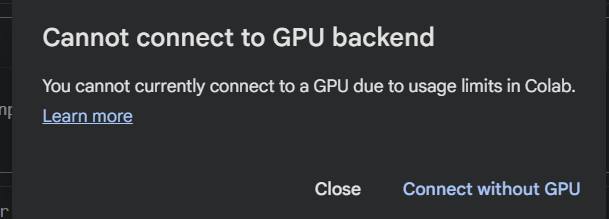

In [20]:
from transformers import pipeline
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [19]:
import pandas as pd

df_test = pd.read_csv(
    '/content/drive/MyDrive/NLP2025/yelp/yelp/test_en.txt',
    sep='\t',
    names=['Sentence','Style','User'],
    header=0,
    on_bad_lines='skip',
    engine='python'
).dropna()

label_map = {"positive": 1, "negative": 0}
df_test["Style"] = df_test["Style"].map(label_map)

df_test["Sentence"] = (
    df_test["Sentence"]
    .astype(str)
    .str.replace('\n', ' ', regex=False)
    .str.strip()
)

test_texts = df_test["Sentence"].tolist()
test_labels = df_test["Style"].tolist()

df_test.head()

,Sentence,Style,User
0,The hubby and I have been here on multiple occ...,1,j2wlzrntrbKwyOcOiB3l3w
1,Meh is all I can say for TDS. The restaurant i...,0,kHmXUEOAsIbguUrPoX6Tkg
2,I stopped in because I was hungry for some sna...,1,gasLVm0KRwrVhPGRcqATjw
3,Here's an update for my further Comcast experi...,0,RycuS3TlPJKYCN6jaqgc7w
4,My wife bought a car here. I handled the nego...,0,NfoAmvEZ3NVTAtOEshCvwQ


In [32]:
test_texts_small = test_texts[:10]
test_labels_small = test_labels[:10]

## Zero-shot BART

In [33]:
zero_shot_bart = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

preds_bart = []
for text in test_texts_small:
    output = zero_shot_bart(
        text,
        candidate_labels=["positive", "negative"]
    )
    preds_bart.append(1 if output["labels"][0] == "positive" else 0)


Device set to use cpu


In [34]:
preds_bart

[1, 0, 1, 0, 0, 1, 1, 1, 1, 1]

In [35]:
zero_shot_t5 = pipeline(
    "text2text-generation",
    model="google/flan-t5-large"
)

preds_t5 = []
for text in test_texts_small:
    prompt = f"Classify the sentiment as positive or negative:\n{text}"
    output = zero_shot_t5(prompt)[0]["generated_text"].lower()
    preds_t5.append(1 if "positive" in output else 0)

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cpu


In [36]:
preds_t5

[1, 0, 1, 0, 0, 1, 1, 1, 1, 0]

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(true_labels, predicted):
    print("Accuracy :", accuracy_score(true_labels, predicted))
    print("Recall   :", recall_score(true_labels, predicted))
    print("F1-score :", f1_score(true_labels, predicted))

In [38]:
print("\nZero-shot BART:")
evaluate(test_labels_small, preds_bart)

print("\nZero-shot T5:")
evaluate(test_labels_small, preds_t5)


Zero-shot BART:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Zero-shot T5:
Accuracy : 0.9
Precision: 1.0
Recall   : 0.8571428571428571
F1-score : 0.9230769230769231


In [40]:
fewshot_examples = """
Review: The food was amazing and the service was friendly.
Sentiment: positive

Review: The food was terrible and the service was slow.
Sentiment: negative
"""

In [41]:
preds_bart_few = []
for text in test_texts_small:
    prompt = fewshot_examples + f"\nReview: {text}\nSentiment:"
    output = zero_shot_bart(
        prompt,
        candidate_labels=["positive", "negative"]
    )
    preds_bart_few.append(1 if output["labels"][0] == "positive" else 0)

In [42]:
preds_bart_few

[1, 0, 1, 0, 0, 1, 0, 1, 1, 1]

In [43]:
preds_t5_few = []
for text in test_texts_small:
    prompt = fewshot_examples + f"\nReview: {text}\nSentiment:"
    output = zero_shot_t5(prompt)[0]["generated_text"].lower()
    preds_t5_few.append(1 if "positive" in output else 0)

In [44]:
preds_t5_few

[1, 0, 1, 0, 0, 1, 1, 1, 1, 0]

In [45]:
print("\nFew-shot BART:")
evaluate(test_labels_small, preds_bart_few)

print("\nFew-shot T5:")
evaluate(test_labels_small, preds_t5_few)


Few-shot BART:
Accuracy : 0.9
Recall   : 0.8571428571428571
F1-score : 0.9230769230769231

Few-shot T5:
Accuracy : 0.9
Recall   : 0.8571428571428571
F1-score : 0.9230769230769231


Иако овие модели се seq2seq и се флексибилни за zero-shot и few-shot задачи, со поголем капацитет и можност да разберат инструкции, разликата во перформансите во споредба со финетјунирани RoBERTa и DistilBERT е најверојатно малa за бинарна класификација на сентиментот. RoBERTa и DistilBERT, со својата encoder-only архитектура и фулл финетјунинг на истиот датасет, можат да постигнат високи резултати, додека T5 и BART ја покажуваат предноста главно при мал број примери како во моето тестирање.

Вистинска евалуација за компарација треба реално да се направи на големо податочно множество какво и што имаме, но сепак временското ограничувањето поради неможност за користење на GPU спречи да се дојде до пореален заклучок...